<a href="https://colab.research.google.com/github/elisama-of/EstatisticaPPEC/blob/main/Analise_Durabilidade_Concretos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
categories:
- PPEC
- Ensino
- Estatística
date: 2026-07-09
description: Terceira Aula
image: parametros.png
title: "Aula 3 - Estimativa de Parâmetros"
---

# Análise Estatística da Durabilidade de Concretos

Este estudo aplica conceitos de estimação de parâmetros na análise da durabilidade de concretos convencionais, CAD e UHPC.

Foram avaliados dois mecanismos de degradação: carbonatação e penetração de cloretos, com o objetivo de verificar a relação entre esses fenômenos e comparar o desempenho dos materiais.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Base de dados simulada

Foram considerados ensaios de profundidade de carbonatação e penetração de cloretos em diferentes tipos de concreto.

In [14]:
import pandas as pd

# Identificação
cp = ["CP1", "CP2", "CP3", "CP4", "CP5", "CP6", "CP7", "CP8", "CP9"]

# Tipo de concreto
tipo = [
    "Convencional", "Convencional", "Convencional",
    "CAD", "CAD", "CAD",
    "UHPC", "UHPC", "UHPC"
]

# Carbonatação (mm)
carbonatacao = [12, 14, 13, 8, 7, 9, 2, 3, 2]

# Penetração de cloretos (mm)
cloretos = [25, 28, 26, 15, 14, 16, 5, 6, 4]

# DataFrame
dados = pd.DataFrame({
    "CP": cp,
    "Tipo": tipo,
    "Carbonatação (mm)": carbonatacao,
    "Cloretos (mm)": cloretos
})

dados.index = dados.index + 1

dados


,CP,Tipo,Carbonatação (mm),Cloretos (mm)
1,CP1,Convencional,12,25
2,CP2,Convencional,14,28
3,CP3,Convencional,13,26
4,CP4,CAD,8,15
5,CP5,CAD,7,14
6,CP6,CAD,9,16
7,CP7,UHPC,2,5
8,CP8,UHPC,3,6
9,CP9,UHPC,2,4


## Estimação da média e Intervalo de confiança (95%)

Cálculo das médias dos parâmetros de durabilidade para cada tipo de concreto e estimativa da faixa provável dos parâmetros de durabilidade..

In [18]:
for t in dados["Tipo"].unique():
    valores = dados[dados["Tipo"] == t]["Carbonatação (mm)"]

    media = valores.mean()
    desvio = valores.std()
    n = len(valores)

    erro = 1.96 * (desvio / np.sqrt(n))

    print(t)
    print("Média:", media)
    print("IC:", media - erro, "até", media + erro)
    print()

Convencional
Média: 13.0
IC: 11.868393472388334 até 14.131606527611666

CAD
Média: 8.0
IC: 6.868393472388333 até 9.131606527611666

UHPC
Média: 2.3333333333333335
IC: 1.6800000000000002 até 2.986666666666667



## Correlação entre carbonatação e penetração de cloretos

Avaliação da relação entre os mecanismos de degradação.

In [22]:
r = dados["Carbonatação (mm)"].corr(dados["Cloretos (mm)"])

print(f"Coeficiente de correlação (r): {r:.2f}")

Coeficiente de correlação (r): 1.00


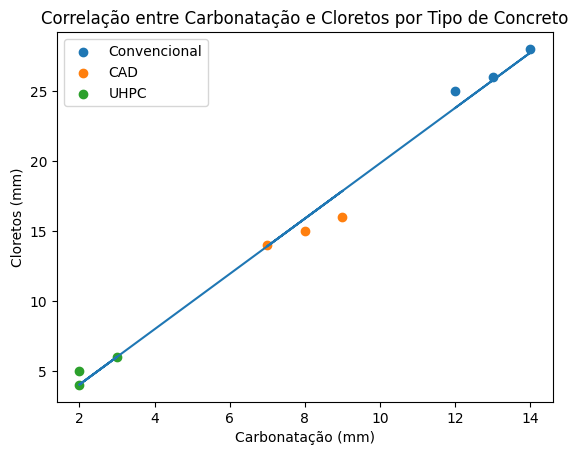

In [25]:
import matplotlib.pyplot as plt

# Separando os dados por tipo
conv = dados[dados["Tipo"] == "Convencional"]
cad = dados[dados["Tipo"] == "CAD"]
uhpc = dados[dados["Tipo"] == "UHPC"]

# Plot
plt.scatter(conv["Carbonatação (mm)"], conv["Cloretos (mm)"], label="Convencional")
plt.scatter(cad["Carbonatação (mm)"], cad["Cloretos (mm)"], label="CAD")
plt.scatter(uhpc["Carbonatação (mm)"], uhpc["Cloretos (mm)"], label="UHPC")

# Linha de tendência geral
import numpy as np
x = dados["Carbonatação (mm)"]
y = dados["Cloretos (mm)"]
coef = np.polyfit(x, y, 1)
linha = np.poly1d(coef)

plt.plot(x, linha(x))

# Ajustes
plt.xlabel("Carbonatação (mm)")
plt.ylabel("Cloretos (mm)")
plt.title("Correlação entre Carbonatação e Cloretos por Tipo de Concreto")
plt.legend()

plt.show()

## Comparação dos parâmetros de durabilidade

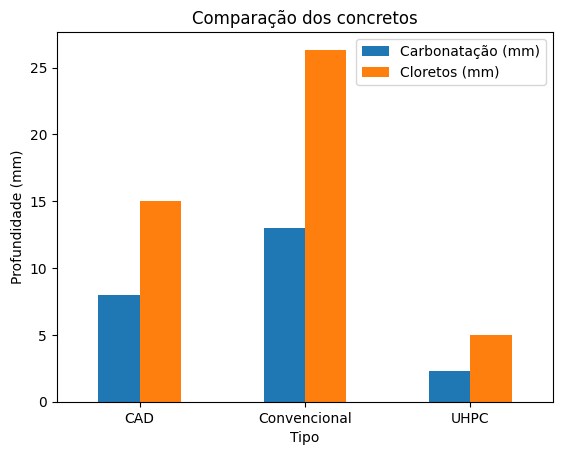

In [29]:
# Garantir que as colunas são numéricas
dados["Carbonatação (mm)"] = pd.to_numeric(dados["Carbonatação (mm)"])
dados["Cloretos (mm)"] = pd.to_numeric(dados["Cloretos (mm)"])

# Calcular médias
medias = dados.groupby("Tipo")[["Carbonatação (mm)", "Cloretos (mm)"]].mean()

# Plot
medias.plot(kind="bar")

plt.title("Comparação dos concretos")
plt.ylabel("Profundidade (mm)")
plt.xticks(rotation=0)

plt.show()

## Conclusões

A análise estatística permitiu avaliar a relação entre diferentes mecanismos de degradação do concreto. Observou-se uma forte correlação entre a profundidade de carbonatação e a penetração de cloretos, indicando que ambos estão associados à porosidade e à microestrutura do material.
Os concretos de maior desempenho, como o UHPC, apresentaram menores valores para os parâmetros analisados, evidenciando maior durabilidade.
 Além disso, a aplicação de intervalos de confiança possibilitou avaliar a variabilidade dos resultados, contribuindo para uma análise mais robusta dos dados experimentais.

## Considerações finais

O uso de técnicas de estimação de parâmetros e análise de correlação mostrou-se fundamental para interpretar os resultados experimentais e compreender o comportamento dos materiais.

Essas ferramentas permitem não apenas descrever os dados, mas também inferir tendências e avaliar a confiabilidade dos resultados, sendo essenciais em estudos de durabilidade de concretos.